# Step 2 — feature association with each horizon target

The target is transformed with `log1p` because view counts are extremely skewed. Numeric and boolean features use signed Spearman correlation. Categorical features use eta-squared because assigning arbitrary numeric codes to categories would produce misleading correlations. Canonical topics already arrive as separate binary indicators, so rare full topic combinations are never treated as categories.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.api.types import is_bool_dtype, is_numeric_dtype

HORIZONS = (7, 14, 21, 30)
project_root = Path.cwd()
if not (project_root / "Dataset").exists():
    project_root = project_root.parent

input_dir = project_root / "Dataset" / "model_horizon_datasets"
output_dir = project_root / "results" / "correlation_maps"
output_dir.mkdir(parents=True, exist_ok=True)

horizon_datasets = {
    horizon: pd.read_csv(input_dir / f"viewcastlk_day_{horizon}.csv", low_memory=False)
    for horizon in HORIZONS
}
print({f"day_{h}": len(frame) for h, frame in horizon_datasets.items()})

{'day_7': 20455, 'day_14': 15599, 'day_21': 15058, 'day_30': 14741}


In [2]:
def spearman_with_target(feature: pd.Series, target_log: pd.Series) -> float:
    numeric = pd.to_numeric(feature, errors="coerce")
    valid = numeric.notna() & target_log.notna()
    if valid.sum() < 2 or numeric.loc[valid].nunique() < 2:
        return np.nan
    return float(numeric.loc[valid].corr(target_log.loc[valid], method="spearman"))


def eta_squared(feature: pd.Series, target_log: pd.Series) -> float:
    categories = feature.astype("string").fillna("__MISSING__")
    valid = target_log.notna()
    categories = categories.loc[valid]
    values = target_log.loc[valid].astype(float)
    if len(values) < 2 or categories.nunique() < 2:
        return np.nan
    grand_mean = values.mean()
    total_variation = float(((values - grand_mean) ** 2).sum())
    if total_variation == 0:
        return np.nan
    grouped = pd.DataFrame({"category": categories, "target": values}).groupby("category")["target"]
    counts = grouped.size()
    means = grouped.mean()
    between_variation = float((counts * (means - grand_mean) ** 2).sum())
    return between_variation / total_variation


def annotated_heatmap(matrix: pd.DataFrame, title: str, output_path: Path, *, signed: bool) -> None:
    values = matrix.to_numpy(dtype=float)
    finite = np.abs(values[np.isfinite(values)])
    limit = max(0.10, float(finite.max())) if len(finite) else 1.0
    vmin, vmax, cmap = (-limit, limit, "coolwarm") if signed else (0.0, limit, "YlGnBu")
    figure, axis = plt.subplots(figsize=(8, max(4, 0.42 * len(matrix))))
    image = axis.imshow(values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    axis.set_xticks(range(len(matrix.columns)), matrix.columns)
    axis.set_yticks(range(len(matrix.index)), matrix.index)
    axis.set_title(title, pad=14)
    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            value = values[row, column]
            axis.text(column, row, "—" if np.isnan(value) else f"{value:.3f}", ha="center", va="center", fontsize=8)
    figure.colorbar(image, ax=axis, shrink=0.8)
    figure.tight_layout()
    figure.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()

In [3]:
numeric_rows = []
categorical_rows = []
predictors_by_horizon = {}

for horizon, frame in horizon_datasets.items():
    target_column = f"d{horizon}_views"
    target_log = np.log1p(pd.to_numeric(frame[target_column], errors="coerce"))
    predictors = [column for column in frame.columns if column != target_column]
    predictors_by_horizon[horizon] = predictors

    for feature in predictors:
        series = frame[feature]
        if is_numeric_dtype(series.dtype) or is_bool_dtype(series.dtype):
            numeric_rows.append({
                "feature": feature, "horizon": f"day_{horizon}",
                "spearman_log_target": spearman_with_target(series, target_log),
            })
        else:
            levels = int(series.nunique(dropna=False))
            categorical_rows.append({
                "feature": feature, "horizon": f"day_{horizon}",
                "eta_squared_log_target": eta_squared(series, target_log),
                "levels": levels, "high_cardinality": levels > 50,
            })

numeric_correlations = pd.DataFrame(numeric_rows)
categorical_associations = pd.DataFrame(categorical_rows)
numeric_matrix = numeric_correlations.pivot(index="feature", columns="horizon", values="spearman_log_target")
categorical_matrix = categorical_associations.pivot(index="feature", columns="horizon", values="eta_squared_log_target")
column_order = [f"day_{horizon}" for horizon in HORIZONS]
numeric_matrix = numeric_matrix.reindex(columns=column_order)
categorical_matrix = categorical_matrix.reindex(columns=column_order)

numeric_correlations.to_csv(output_dir / "numeric_target_correlations.csv", index=False)
categorical_associations.to_csv(output_dir / "categorical_target_associations.csv", index=False)

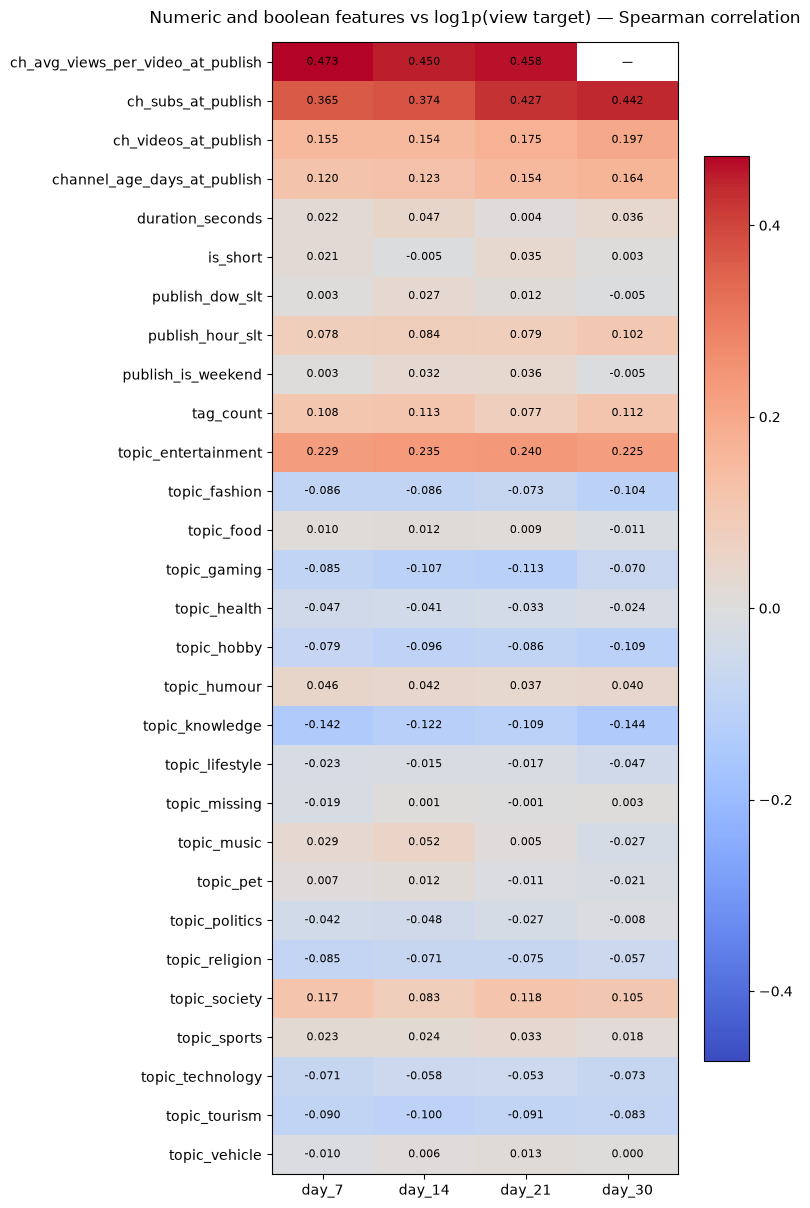

In [4]:
annotated_heatmap(
    numeric_matrix,
    "Numeric and boolean features vs log1p(view target) — Spearman correlation",
    output_dir / "numeric_target_correlations.png",
    signed=True,
)

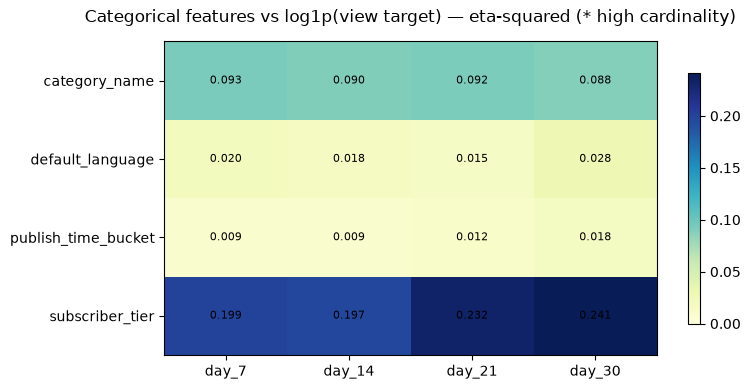

In [5]:
high_cardinality_features = set(
    categorical_associations.loc[categorical_associations["high_cardinality"], "feature"]
)
categorical_display = categorical_matrix.copy()
categorical_display.index = [
    f"{feature} *" if feature in high_cardinality_features else feature
    for feature in categorical_display.index
]
annotated_heatmap(
    categorical_display,
    "Categorical features vs log1p(view target) — eta-squared (* high cardinality)",
    output_dir / "categorical_target_associations.png",
    signed=False,
)

In [6]:
expected_horizons = {f"day_{horizon}" for horizon in HORIZONS}
assert set(numeric_correlations["horizon"]) == expected_horizons
assert set(categorical_associations["horizon"]) == expected_horizons
assert numeric_correlations["spearman_log_target"].dropna().between(-1, 1).all()
assert categorical_associations["eta_squared_log_target"].dropna().between(0, 1).all()
for horizon in HORIZONS:
    numeric_features = set(numeric_correlations.loc[numeric_correlations["horizon"] == f"day_{horizon}", "feature"])
    categorical_features = set(categorical_associations.loc[categorical_associations["horizon"] == f"day_{horizon}", "feature"])
    assert numeric_features.isdisjoint(categorical_features)
    assert numeric_features | categorical_features == set(predictors_by_horizon[horizon])
assert (output_dir / "numeric_target_correlations.png").exists()
assert (output_dir / "categorical_target_associations.png").exists()
print(f"PASS: {len(numeric_matrix)} numeric/boolean and {len(categorical_matrix)} categorical features mapped across all four horizons")

PASS: 29 numeric/boolean and 4 categorical features mapped across all four horizons
